In [27]:
import pandas as pd
import hvplot.pandas
import panel as pn
import hvplot
import plotly.express as px
pn.extension()


In [13]:
df = pd.read_csv("cleaned_data.csv")

In [14]:
df_trend = df[df['Year'] < 2004]

df_trend

,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,...,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source,Weapon_Group,Relationship_Group,Perpetrator_Age_Available
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1.0,Murder or Manslaughter,...,Native American/Alaska Native,NaN,Acquaintance,Blunt Object,0.0,0.0,FBI,Blunt Object,Known,True
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Strangulation,0.0,0.0,FBI,Other,Known,True
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2.0,Murder or Manslaughter,...,NaN,NaN,NaN,NaN,0.0,0.0,FBI,Unknown,Unknown,False
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Strangulation,0.0,0.0,FBI,Other,Known,True
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2.0,Murder or Manslaughter,...,NaN,NaN,NaN,NaN,0.0,1.0,FBI,Unknown,Unknown,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465681,465682,WY01301,Casper,Municipal Police,Natrona,Wyoming,2003,August,1.0,Murder or Manslaughter,...,White,NaN,Son,Blunt Object,0.0,0.0,FBI,Blunt Object,Family,True
465682,465683,WY01301,Casper,Municipal Police,Natrona,Wyoming,2003,September,1.0,Murder or Manslaughter,...,White,NaN,Wife,Blunt Object,0.0,0.0,FBI,Blunt Object,Partner,True
465683,465684,WY01304,Evansville,Municipal Police,Natrona,Wyoming,2003,July,1.0,Murder or Manslaughter,...,White,NaN,Acquaintance,Blunt Object,0.0,0.0,FBI,Blunt Object,Known,True
465684,465685,WY01900,Sweetwater,Sheriff,Sweetwater,Wyoming,2003,January,1.0,Murder or Manslaughter,...,White,NaN,In-Law,Rifle,0.0,0.0,FBI,Firearm,Other,True


In [15]:
yearly_incidents = (
    df_trend[['Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('Year')
    .size()
    .reset_index(name='Total_Incidents')
)

yearly_incidents

,Year,Total_Incidents
0,1980,17056
1,1981,15963
2,1982,15157
3,1983,14868
4,1984,13429
5,1985,13490
6,1986,14887
7,1987,13897
8,1988,14494
9,1989,15271


In [16]:
year_slider = pn.widgets.IntRangeSlider(
    name='Select Year Range',
    start=yearly_incidents['Year'].min(),
    end=yearly_incidents['Year'].max(),
    value=(yearly_incidents['Year'].min(), yearly_incidents['Year'].max())
)

In [17]:
@pn.depends(year_slider)
def trend_plot(year_range):
    filtered = yearly_incidents[
        (yearly_incidents['Year'] >= year_range[0]) &
        (yearly_incidents['Year'] <= year_range[1])
    ]

    return filtered.hvplot.line(
        x='Year',
        y='Total_Incidents',
        line_width=3,
        color='#00D4FF',
        title="Incident Trend Over Time",
        height=400,
        width=800
    ).opts(
        bgcolor='#0A0F1C',
        show_grid=False
    )

In [18]:
pn.Column(year_slider, trend_plot)

Column
    [0] IntRangeSlider(end=np.int64(2003), name='Select Year Range', start=np.int64(1980), value=(np.int64(1980), ..., value_end=np.int64(2003), value_start=np.int64(1980))
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

### Incidents follow a phased pattern, peaking sharply around 1992–93 before a sustained decline through the late 1990s. The drop is steep and consistent, indicating a structural shift rather than random fluctuation, with partial stabilization observed after 2000.

#### The pattern suggests that the variation is not random noise but occurs in distinct phases, indicating underlying systemic factors influencing crime rates rather than isolated yearly changes.

In [22]:
state_data = (
    df_trend[['State', 'Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('State')
    .size()
    .reset_index(name='Total_Incidents')
    .sort_values(by='Total_Incidents', ascending=False)
)

top_states = state_data.head(10)
top_states

,State,Total_Incidents
4,California,42583
43,Texas,38351
32,New York,37906
13,Illinois,18375
22,Michigan,17827
9,Florida,15077
38,Pennsylvania,14154
10,Georgia,12957
18,Louisiana,12701
33,North Carolina,12341


In [23]:
top_states.hvplot.barh(
    x='State',
    y='Total_Incidents',
    color='#7B61FF',
    title="Top 10 States by Incidents",
    height=400,
    width=800
).opts(
    bgcolor='#0A0F1C',
    show_grid=False,
    tools=['hover'],
    toolbar='right'
)

:Bars   [State]   (Total_Incidents)

### Crime incidents are highly concentrated, with California clearly dominating, followed by Texas and New York. A sharp drop after the top three indicates that a small number of states account for a disproportionately large share of total incidents.

#### This distribution suggests that crime is not evenly spread geographically, but clustered in high-population or high-density states.

In [36]:
weapon_data = (
    df_trend[['Weapon_Group', 'Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('Weapon_Group')
    .size()
    .reset_index(name='Total_Incidents')
    .sort_values(by='Total_Incidents', ascending=False)
)

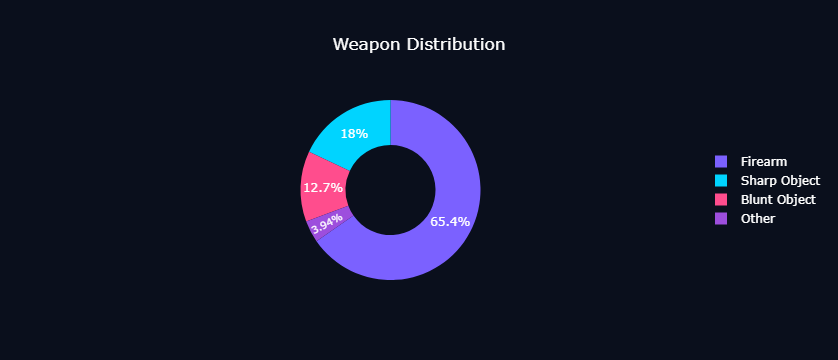

In [43]:
top_weapons = (
    weapon_data[weapon_data['Weapon_Group'] != 'Unknown']
    .head(6)
)

fig = px.pie(
    top_weapons,
    names='Weapon_Group',
    values='Total_Incidents',
    hole=0.5,
    color_discrete_sequence=[
        '#7B61FF', '#00D4FF', '#FF4D8D',
        '#9D4EDD', '#4CC9F0', '#F72585'
    ],
    title="Weapon Distribution"
)
fig.update_layout(
    paper_bgcolor='#0A0F1C',
    plot_bgcolor='#0A0F1C',
    font_color='white',
    title_x=0.5   # center title
)

fig.update_traces(
    textinfo='percent',
    textposition='inside',
    textfont=dict(color='white')
)
fig.update_layout(
    legend=dict(
        orientation="v",
        x=1,
        y=0.5
    )
)
fig.show()

#### The distribution clearly shows a strong concentration in firearm usage, which suggests that incident methods are not diverse but heavily reliant on a single dominant category. This could indicate factors such as accessibility, effectiveness, or reporting bias influencing weapon choice.

In [38]:
relationship_data = (
    df_trend[['Relationship_Group', 'Year', 'Month', 'City', 'Incident']]
    .drop_duplicates()
    .groupby('Relationship_Group')
    .size()
    .reset_index(name='Total_Incidents')
    .sort_values(by='Total_Incidents', ascending=False)
)

relationship_data

,Relationship_Group,Total_Incidents
6,Unknown,155008
1,Known,107106
5,Stranger,63947
3,Partner,43854
0,Family,17973
2,Other,9441
4,Sibling,4971


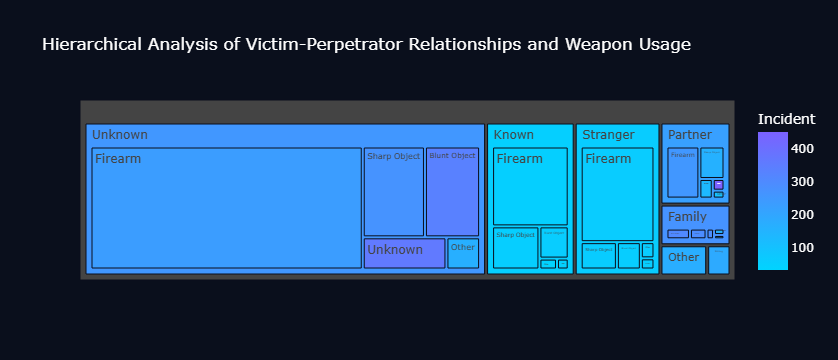

In [47]:
top_rel = relationship_data.head(6)

fig = px.treemap(
    df_trend,
    path=['Relationship_Group', 'Weapon_Group'],
    values='Incident',
    color='Incident',
    color_continuous_scale=['#00D4FF', '#7B61FF'],
    title="Hierarchical Analysis of Victim-Perpetrator Relationships and Weapon Usage"
)

fig.update_layout(
    paper_bgcolor='#0A0F1C',
    font_color='white'
)

fig.update_traces(
    hovertemplate="<b>%{label}</b><br>Incidents: %{value}<extra></extra>"
)

fig.show()

### A large proportion of incidents fall under unknown relationships, with firearms dominating across most categories, indicating both data limitations and strong weapon concentration patterns.